# Exploratory Data Analysis (EDA)
## Lagos & Abuja Rent Prediction
## 3MTT Capstone Project

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

In [10]:
# Load the Cleaned Dataset
df = pd.read_csv("../data/processed/rent_clean_v2.csv")

In [7]:
df.head()

,Title,More Info,Location,Price,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets
0,Newly Built 4 Bedroom Semi Detached House With Bq,4 BEDROOM HOUSE FOR RENT,"White Oak Estate, Ologolo Opp. Agungi, Ologolo...",5000000.0,0,1,0,4.0,4.0,5.0
1,Superb 4 Bedroom Semi Detached Duplex With Bq,4 BEDROOM HOUSE FOR RENT,"Hrc Estate Beside Vgc Estate, Vgc Lekki Lagos",5000000.0,0,1,0,4.0,4.0,5.0
2,Furnished 2 Bedroom Terrace Duplex For Rent !!!,2 BEDROOM HOUSE FOR RENT,Osapa London Lekki Lagos,3500000.0,1,0,0,2.0,3.0,3.0
3,2 Bedroom Apartment For Rent,2 BEDROOM HOUSE FOR RENT,Ologolo Lekki Lagos,2700000.0,1,1,0,2.0,3.0,3.0
4,?? Brand New 2 Bedroom Flat For Rent!!! (groun...,2 BEDROOM HOUSE FOR RENT,Mojisola Onikoyi Ikoyi Lagos,5000000.0,1,1,0,2.0,3.0,3.0


In [11]:
# Confirm the Shape
df.shape

(97225, 10)

In [12]:
# Generate Descriptive Statistics
df.describe()

,Price,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets
count,9.722500e+04,97225.000000,97225.000000,97225.000000,97225.000000,97225.000000,97225.000000
mean,4.263248e+07,0.162684,0.299913,0.120597,2.283353,2.118745,2.489905
std,6.757220e+09,0.369079,0.458222,0.325660,1.419683,1.576755,1.827961
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000e+05,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,1.300000e+06,0.000000,0.000000,0.000000,2.000000,2.000000,3.000000
75%,3.500000e+06,0.000000,1.000000,0.000000,3.000000,3.000000,4.000000
max,1.700000e+12,1.000000,1.000000,1.000000,10.000000,10.000000,10.000000


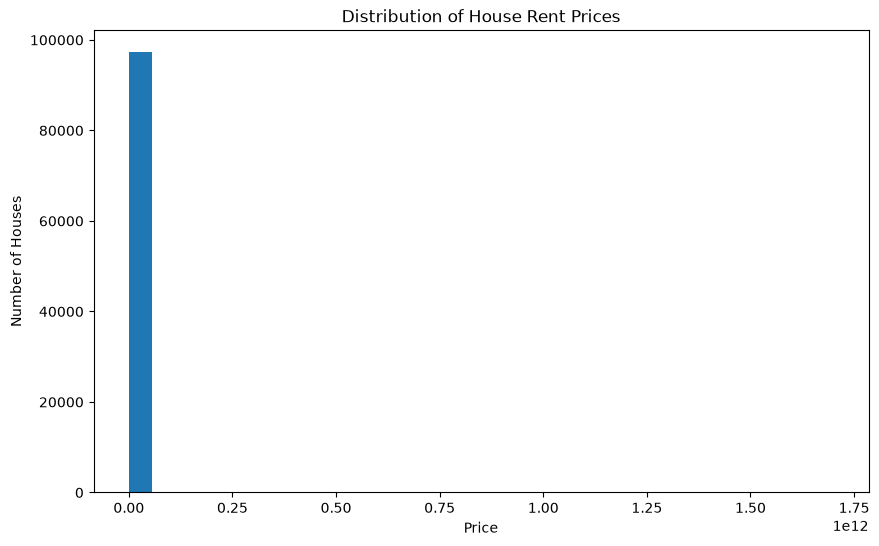

In [13]:
# Examine the Price Distribution using histogram
plt.figure(figsize=(10,6))
plt.hist(df["Price"], bins=30)
plt.title("Distribution of House Rent Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_26464\2943256482.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Price"], vert=False)


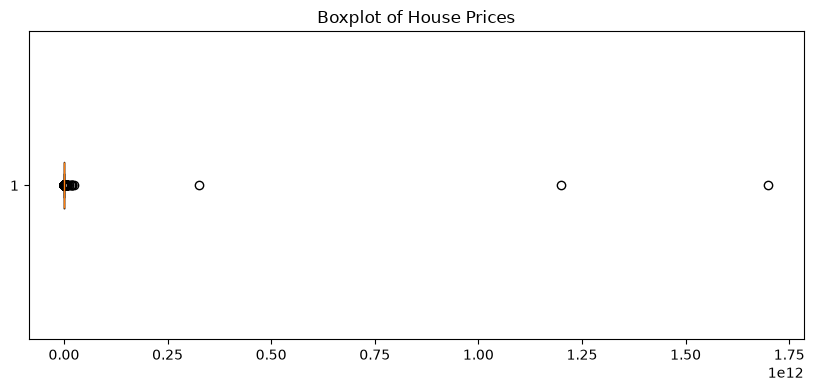

In [14]:
# Checking for Outliers using boxplot
plt.figure(figsize=(10,4))
plt.boxplot(df["Price"], vert=False)
plt.title("Boxplot of House Prices")
plt.show()

In [8]:
# Which Columns Are Numeric?
df.select_dtypes(include=["number"]).columns

Index(['Price', 'Serviced', 'Newly Built', 'Furnished', 'Bedrooms',
       'Bathrooms', 'Toilets'],
      dtype='str')

In [15]:
# Which Columns Are Text?
df.select_dtypes(include=["object","string"]).columns

Index(['Title', 'More Info', 'Location'], dtype='str')

In [16]:
# Business Questions with EDA
# Question 1. What are the most expensive locations?
df.groupby("Location")["Price"].mean().sort_values(ascending=False).head(10)

Location
George Street, Ikoyi Ikoyi Lagos                                              1.200000e+12
Ojora Cresent Old Ikoyi Ikoyi Lagos                                           3.250000e+11
Victoria Island Lagos. Victoria Island Extension Victoria Island Lagos        2.000000e+10
Victoria Island Extension Victoria Island Lagos                               1.870426e+10
85, Jebba Street, Ebute Metta, East, Lagos State, Nigeria Abule Egba Lagos    1.685062e+10
Sanusi Fafunwa Street Victoria Island Extension Victoria Island Lagos         1.200000e+10
Ikoyi Lagos Awolowo Road Ikoyi Lagos                                          8.000000e+09
Directly Off Fola Osibo Lekki Phase 1 Lekki Lagos                             7.000000e+09
Off Ishaga Rd Via (luth) Surulere Ojuelegba Surulere Lagos                    5.000550e+09
Off Monastery Road Sangotedo Sangotedo Ajah Lagos                             5.000000e+09
Name: Price, dtype: float64

In [23]:
# Question 2. What is the average rent by number of bedrooms?
df.groupby("Bedrooms")["Price"].mean()

Bedrooms
0.0     1.286485e+08
1.0     3.747754e+06
2.0     2.170437e+07
3.0     8.022426e+06
4.0     1.291936e+07
5.0     4.392230e+08
6.0     2.649876e+07
7.0     1.588757e+08
8.0     1.715151e+07
9.0     5.392437e+08
10.0    1.216720e+08
Name: Price, dtype: float64

In [24]:
# Question 3. Are serviced properties more expensive?
df.groupby("Serviced")["Price"].mean()

Serviced
0    4.887979e+07
1    1.047842e+07
Name: Price, dtype: float64

In [25]:
# Question 4. Are furnished properties more expensive?
df.groupby("Furnished")["Price"].mean()

Furnished
0    4.713608e+07
1    9.791768e+06
Name: Price, dtype: float64

In [26]:
# Question 5. Does a newly built property cost more?
df.groupby("Newly Built")["Price"].mean()

Newly Built
0    3.138410e+07
1    6.888963e+07
Name: Price, dtype: float64

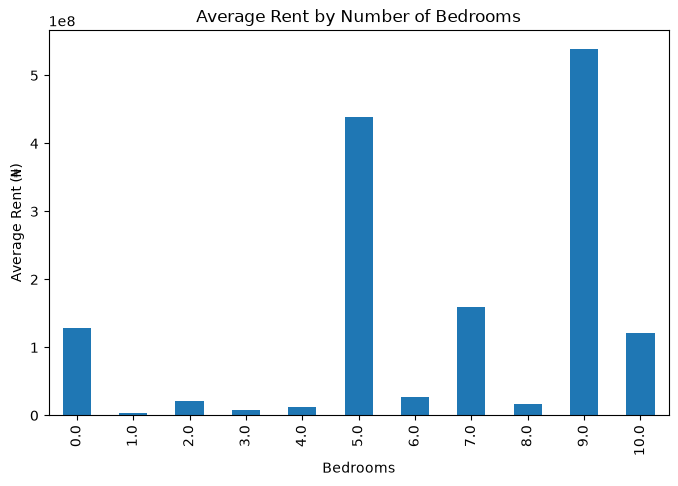

In [27]:
# Visualizing the Results
avg_price_by_bedroom = df.groupby("Bedrooms")["Price"].mean()

plt.figure(figsize=(8,5))
avg_price_by_bedroom.plot(kind="bar")
plt.title("Average Rent by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Rent (₦)")
plt.show()

In [29]:
#Investigating Outliers
#Find the Most Expensive Properties
df.nlargest(20, "Price")[["Title", "Location", "Price"]]

,Title,Location,Price
13900,5 Bedroom Fully Detached Duplex,Victoria Island Extension Victoria Island Lagos,1.700000e+12
7704,Land,"George Street, Ikoyi Ikoyi Lagos",1.200000e+12
6671,Joint Venture Land At Old Ikoyi,Ojora Cresent Old Ikoyi Ikoyi Lagos,3.250000e+11
56056,Brand New 4 Numbers Miniflat For Sale,Off Ishaga Rd Via (luth) Surulere Ojuelegba Su...,2.500000e+10
58686,Executive 15 Floors Office Open Plan Building ...,Victoria Island Lagos. Victoria Island Extensi...,2.000000e+10
70594,*tastefully 12br Detached House @ Victoria Isl...,Eko Atlantic Victoria Island Lagos,2.000000e+10
70647,*tastefully 12br Detached House @ Victoria Isl...,Eko Atlantic Victoria Island Lagos,2.000000e+10
70393,The Plaza Abuja,"85, Jebba Street, Ebute Metta, East, Lagos Sta...",1.685062e+10
3254,4 Bedroom Penthouse,Banana Island Ikoyi Lagos,1.250000e+10
17096,Joint Venture Land At Victoria Island Lagos,Sanusi Fafunwa Street Victoria Island Extensio...,1.200000e+10


In [30]:
# Find the Cheapest Properties
df.nsmallest(20, "Price")[["Title", "Location", "Price"]]

,Title,Location,Price
22377,Warehouse Capacity Of 8ft By 9ft (negotiable),Ojo Ojo Lagos,0.0
30584,2 Bedroom Apartment*,Olive Estate Ago Palace Okota Lagos,1.0
31068,2 Bedroom Flat*,Coustain Apa Road Ebute Metta Yaba Lagos,1.0
38952,Brand New 2 Bed Room Flat,Ago Palace Way Isolo Lagos,1.0
44900,Exeutive 2 Bedroom Service Apartment,"Agunbiade Street, Off Western Avenue, Back Off...",1.0
46524,Newly Built 2 Bedroom Ensuite,Oke Ira Ogba Lagos,1.0
61149,3 Bedroom Flat,Ifako Gbagada Ifako Gbagada Gbagada Lagos,1.0
62061,A Decent And Clean 3bedroom Flat,Walter Silfry Ifako Gbagada Gbagada Lagos,1.0
67322,One Bed Room Flat,Lekki Phase 1 Lekki Lagos,1.0
77542,1. Bedroom Furnished Apartment On Suite We Hav...,Adeola Odeku Victoria Island Lagos,1.0


In [31]:
# Count Zero Prices
(df["Price"] == 0).sum()

np.int64(1)

In [32]:
# See the Zero-Price Listings
df[df["Price"] == 0][["Title", "Location", "Price"]].head(20)

,Title,Location,Price
22377,Warehouse Capacity Of 8ft By 9ft (negotiable),Ojo Ojo Lagos,0.0


In [33]:
# Look at the Top 10 Highest Prices
df["Price"].sort_values(ascending=False).head(10)

13900    1.700000e+12
7704     1.200000e+12
6671     3.250000e+11
56056    2.500000e+10
70594    2.000000e+10
70647    2.000000e+10
58686    2.000000e+10
70393    1.685062e+10
3254     1.250000e+10
17096    1.200000e+10
Name: Price, dtype: float64

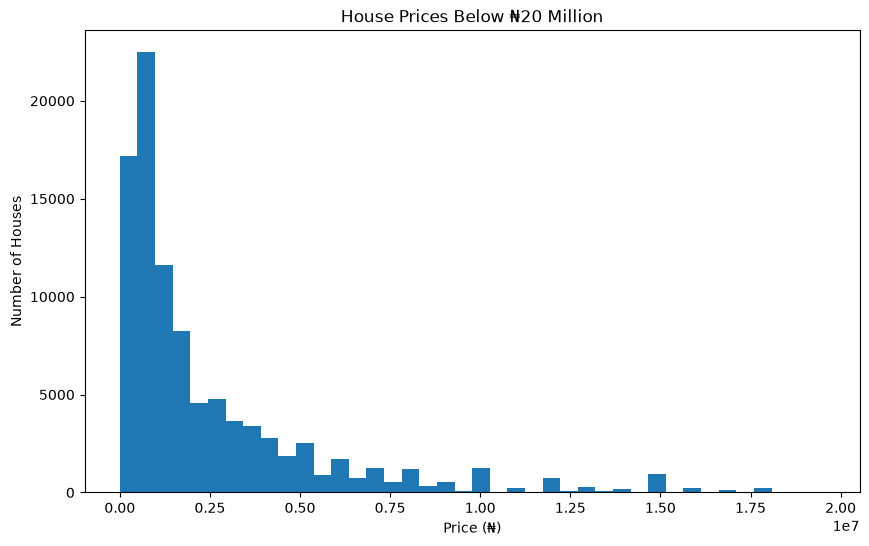

In [34]:
# Create a Better Histogram
plt.figure(figsize=(10,6))

plt.hist(
    df[df["Price"] < 20_000_000]["Price"],
    bins=40
)

plt.title("House Prices Below ₦20 Million")
plt.xlabel("Price (₦)")
plt.ylabel("Number of Houses")

plt.show()